<a href="https://colab.research.google.com/github/nguzman02/Deep-learning_Actividades_Grupal/blob/main/Semana_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importación de librerias
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
#se fija valores aleatorios pero que siempre sean los mismo
np.random.seed(7);
# se carga el dataset completo
data=load_breast_cancer()

In [ ]:
#se define variables de entrada y etiquetas 0 =benigno 1 =maligno
X,y=data.data,data.target
#divide los datos para el entrenamiento definiendo % de prueba y mantenido las proporciones de clase.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7,stratify=y)

print("valores de x",X)
print("valores de y",y)

In [ ]:
#crea un objeto para normailizar los datos
scaler=StandardScaler()
# fit aprender y transfroma datos de entrenamiento  transform aplica lo aprendido a datos de prueba
X_train_s=scaler.fit_transform(X_train); X_test_s=scaler.transform(X_test)


In [ ]:
#se crea un metodo  para una red neuronal
def build(units, lr):
  #crea un modelo secuencial con una capa de entrada segun el numero de variables
    m=keras.Sequential([layers.Input(shape=(X_train_s.shape[1],)),
                        # se crea una cap unitaria con la activación del metodo ReLU
                        layers.Dense(units, activation="relu"),
                        #se crea capa de salida con una neurona y se activa la clasificación binaria
                        layers.Dense(1, activation="sigmoid")])
    #configura el modelo definiendo el modelo como optimizador Adam, funcion de perdida
    #entropia cruzada binaria y una metrica de presición
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    return m

In [1]:
#se define la función para entrenar el modelo
def run(units, lr, batch):
  #construye el modelo
    m=build(units, lr)
    #entrena el modelo definiendo que un 20% como validación
    #define las cantidad de epocas, el tamaño de lote
    h=m.fit(X_train_s,y_train,validation_split=0.2,epochs=30,batch_size=batch,verbose=0)
    #evalua el modelo con datos de prueba
    t=m.evaluate(X_test_s,y_test,verbose=0)
    #retorna datos como hiperparametros usados, la presición en validación y prueba y el error.
    return {"units":units,"lr":lr,"batch":batch,"val_acc":float(h.history["val_accuracy"][-1]),"test_acc":float(t[1]),"test_loss":float(t[0])}
# se genera una lista de convinaciones
configs=[(32,1e-3,32),(64,1e-3,32),(32,5e-4,32),(32,1e-3,64)]
#ejecuta el modelo en cada configuración, guarda los resultados y ordena en mejor presición
df=pd.DataFrame([run(*c) for c in configs]).sort_values("test_acc",ascending=False)
#muestra la tabla de resultados
#df

NameError: name 'pd' is not defined

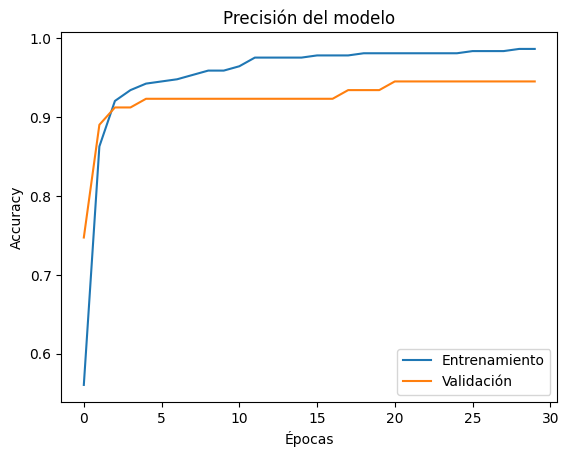

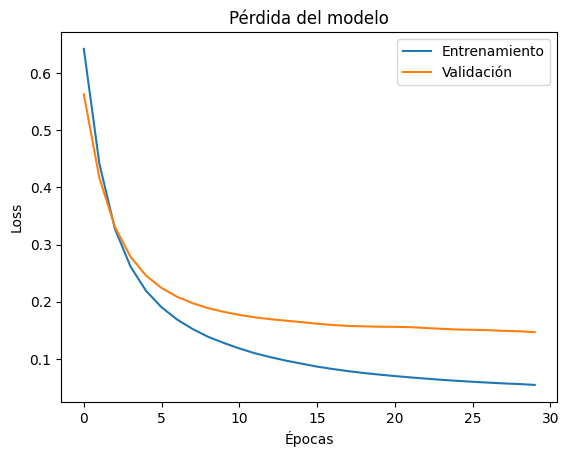

In [ ]:
model_for_plot = build(units=32, lr=0.001)
h = model_for_plot.fit(X_train_s, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=0)
# 📈 GRAFICA ACCURACY
plt.figure()
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

# 📉 GRAFICA LOSS
plt.figure()
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()